# 02 转化漏斗可视化

## 目标
- 构建用户行为转化漏斗：浏览 → 加购 → 收藏 → 购买
- 计算各环节转化率
- 分品类、分时段的漏斗对比分析
- 绘制漏斗图和转化率趋势图

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载清洗后的数据
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'user_behavior_clean.csv')
df = pd.read_csv(DATA_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = pd.to_datetime(df['date'])

print(f'数据加载完成: {len(df):,} 条记录')

数据加载完成: 5,070,824 条记录


## 1. 整体转化漏斗

In [2]:
# 计算各行为的独立用户数
behavior_map = {'pv': '浏览', 'cart': '加购', 'fav': '收藏', 'buy': '购买'}
behavior_order = ['pv', 'cart', 'fav', 'buy']

funnel_data = []
for bt in behavior_order:
    user_count = df[df['behavior_type'] == bt]['user_id'].nunique()
    funnel_data.append({
        '行为': behavior_map[bt],
        '用户数': user_count,
        '转化率(%)': round(user_count / df[df['behavior_type'] == 'pv']['user_id'].nunique() * 100, 2)
    })

funnel_df = pd.DataFrame(funnel_data)
print('=== 整体转化漏斗 ===')
print(funnel_df.to_string(index=False))

=== 整体转化漏斗 ===
行为   用户数  转化率(%)
浏览 49806  100.00
加购 37320   74.93
收藏 19775   39.70
购买 34149   68.56


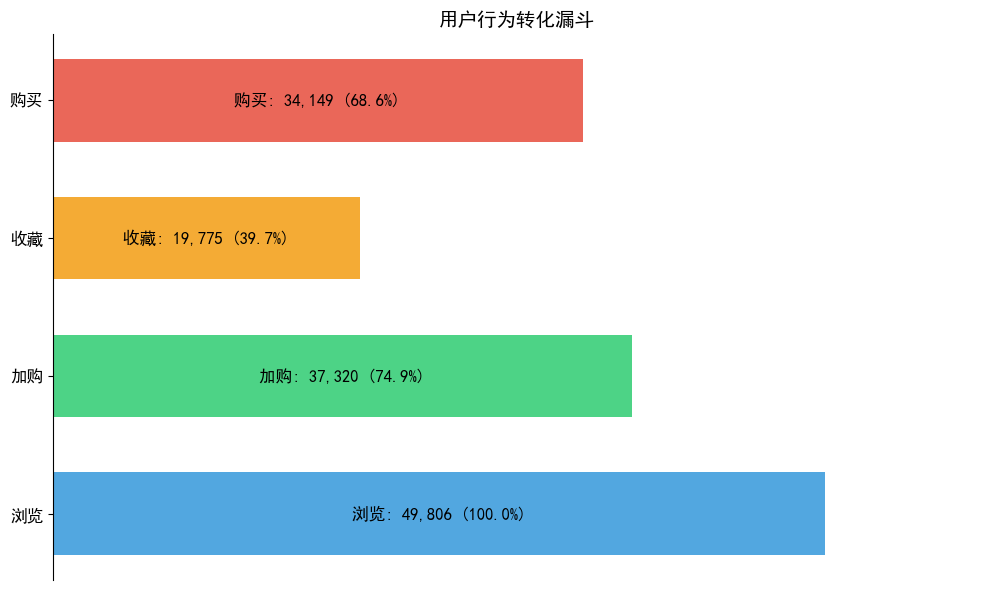

In [3]:
# 绘制漏斗图
from utils import plot_funnel

fig = plot_funnel(df)
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'funnel_overall.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2. 逐步转化率分析

In [4]:
# 计算每一步相对于上一步的转化率
pv_users = set(df[df['behavior_type'] == 'pv']['user_id'])
cart_users = set(df[df['behavior_type'] == 'cart']['user_id'])
fav_users = set(df[df['behavior_type'] == 'fav']['user_id'])
buy_users = set(df[df['behavior_type'] == 'buy']['user_id'])

print('=== 逐步转化率 ===')
print(f'浏览用户数: {len(pv_users):,}')
print(f'浏览→加购: {len(cart_users & pv_users):,} ({len(cart_users & pv_users)/len(pv_users)*100:.2f}%)')
print(f'浏览→收藏: {len(fav_users & pv_users):,} ({len(fav_users & pv_users)/len(pv_users)*100:.2f}%)')
print(f'浏览→购买: {len(buy_users & pv_users):,} ({len(buy_users & pv_users)/len(pv_users)*100:.2f}%)')
print(f'加购→购买: {len(buy_users & cart_users):,} ({len(buy_users & cart_users)/len(cart_users)*100:.2f}%)')
print(f'收藏→购买: {len(buy_users & fav_users):,} ({len(buy_users & fav_users)/len(fav_users)*100:.2f}%)')

=== 逐步转化率 ===
浏览用户数: 49,806
浏览→加购: 37,158 (74.61%)
浏览→收藏: 19,655 (39.46%)
浏览→购买: 33,987 (68.24%)
加购→购买: 26,953 (72.22%)
收藏→购买: 14,105 (71.33%)


## 3. 按日期的转化率趋势

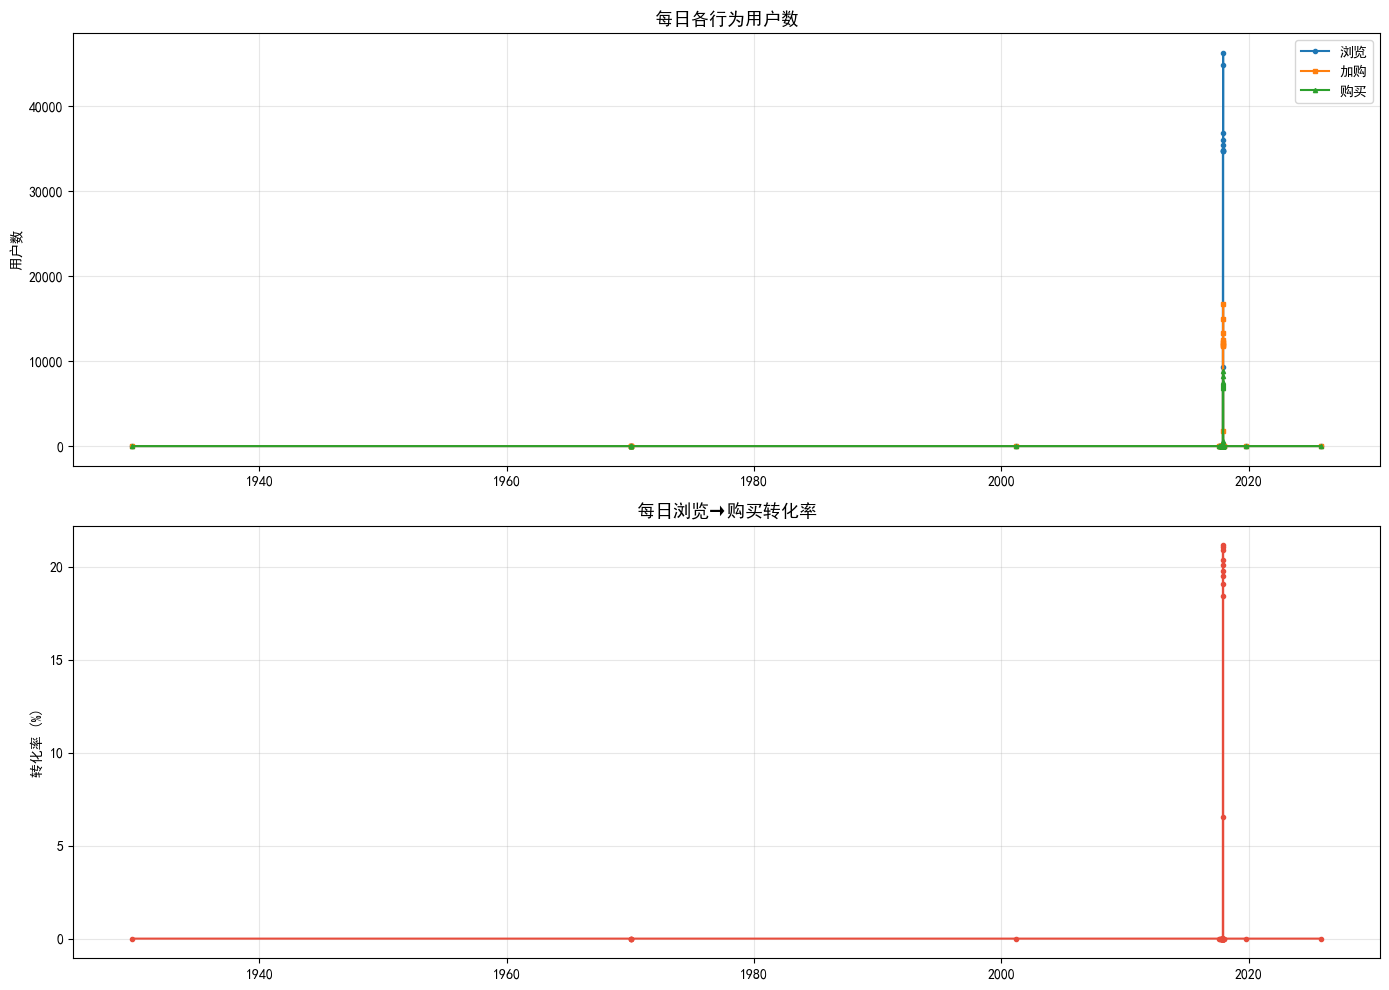

In [5]:
# 按日期计算每日转化率
daily_funnel = df.groupby(['date', 'behavior_type'])['user_id'].nunique().unstack(fill_value=0)

# 确保所有行为列存在
for col in ['pv', 'cart', 'fav', 'buy']:
    if col not in daily_funnel.columns:
        daily_funnel[col] = 0

daily_funnel['pv_to_buy_rate'] = daily_funnel['buy'] / daily_funnel['pv'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 每日各行为用户数
axes[0].plot(daily_funnel.index, daily_funnel['pv'], label='浏览', marker='o', markersize=3)
axes[0].plot(daily_funnel.index, daily_funnel['cart'], label='加购', marker='s', markersize=3)
axes[0].plot(daily_funnel.index, daily_funnel['buy'], label='购买', marker='^', markersize=3)
axes[0].set_title('每日各行为用户数', fontsize=13, fontweight='bold')
axes[0].set_ylabel('用户数')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 每日转化率
axes[1].plot(daily_funnel.index, daily_funnel['pv_to_buy_rate'],
             color='#e74c3c', marker='o', markersize=3)
axes[1].set_title('每日浏览→购买转化率', fontsize=13, fontweight='bold')
axes[1].set_ylabel('转化率 (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'funnel_daily_trend.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 4. 按小时的转化率分析

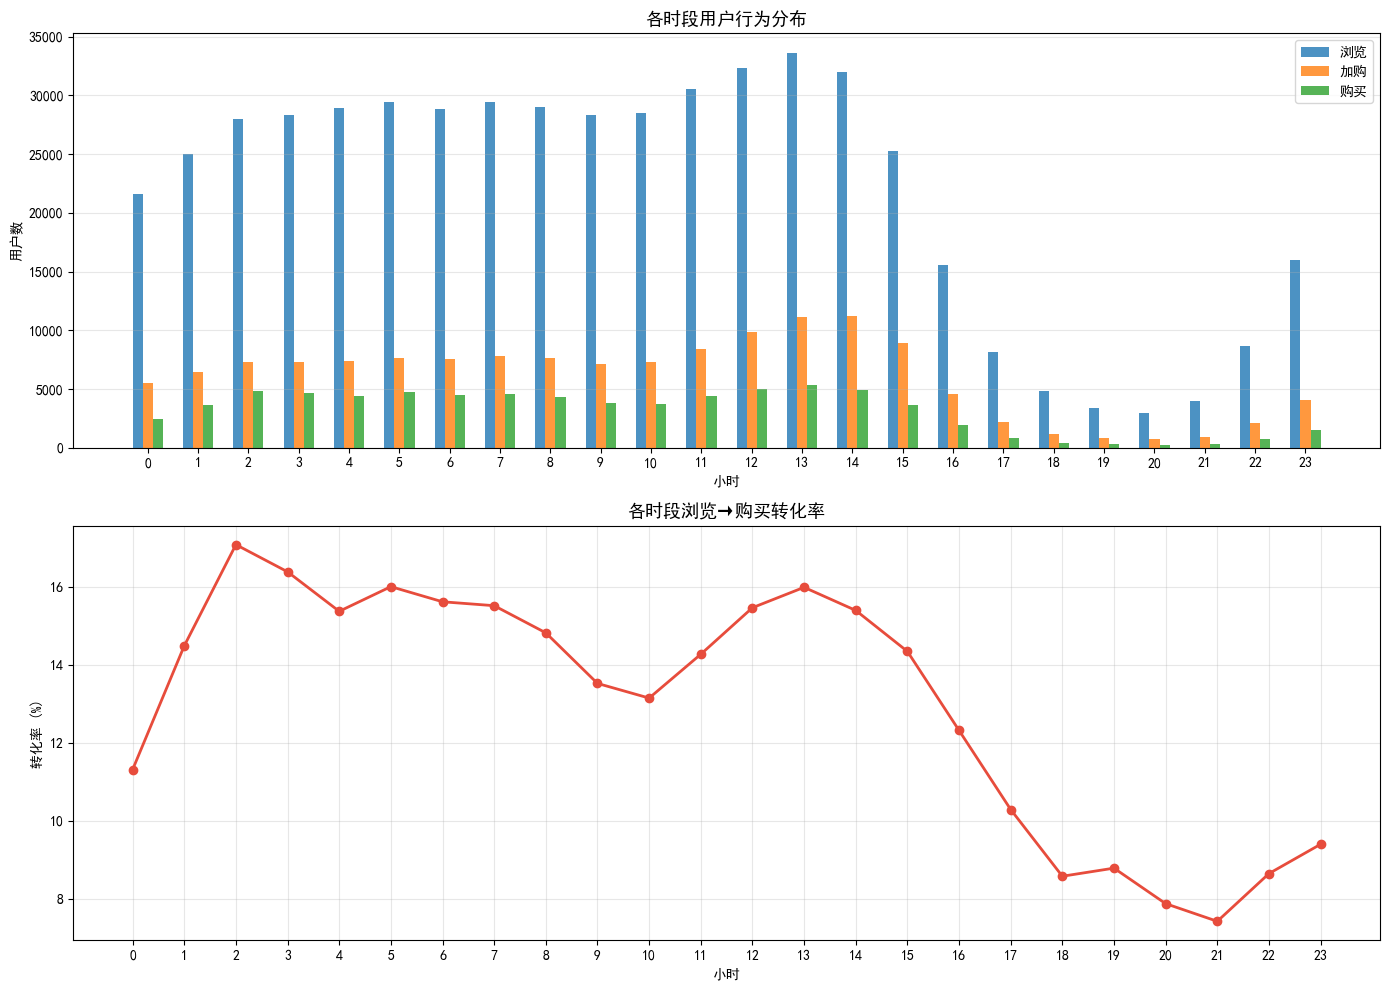


转化率最高时段: 2:00 (17.08%)


In [6]:
# 按小时计算转化率
hourly_funnel = df.groupby(['hour', 'behavior_type'])['user_id'].nunique().unstack(fill_value=0)

for col in ['pv', 'cart', 'fav', 'buy']:
    if col not in hourly_funnel.columns:
        hourly_funnel[col] = 0

hourly_funnel['pv_to_buy_rate'] = hourly_funnel['buy'] / hourly_funnel['pv'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 每小时各行为用户数
axes[0].bar(hourly_funnel.index - 0.2, hourly_funnel['pv'], width=0.2, label='浏览', alpha=0.8)
axes[0].bar(hourly_funnel.index, hourly_funnel['cart'], width=0.2, label='加购', alpha=0.8)
axes[0].bar(hourly_funnel.index + 0.2, hourly_funnel['buy'], width=0.2, label='购买', alpha=0.8)
axes[0].set_title('各时段用户行为分布', fontsize=13, fontweight='bold')
axes[0].set_xlabel('小时')
axes[0].set_ylabel('用户数')
axes[0].set_xticks(range(24))
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 每小时转化率
axes[1].plot(hourly_funnel.index, hourly_funnel['pv_to_buy_rate'],
             color='#e74c3c', marker='o', linewidth=2, markersize=6)
axes[1].set_title('各时段浏览→购买转化率', fontsize=13, fontweight='bold')
axes[1].set_xlabel('小时')
axes[1].set_ylabel('转化率 (%)')
axes[1].set_xticks(range(24))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'funnel_hourly.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 找出高转化时段
best_hour = hourly_funnel['pv_to_buy_rate'].idxmax()
print(f'\n转化率最高时段: {best_hour}:00 ({hourly_funnel["pv_to_buy_rate"].max():.2f}%)')

## 5. 分品类转化漏斗（Top 10）

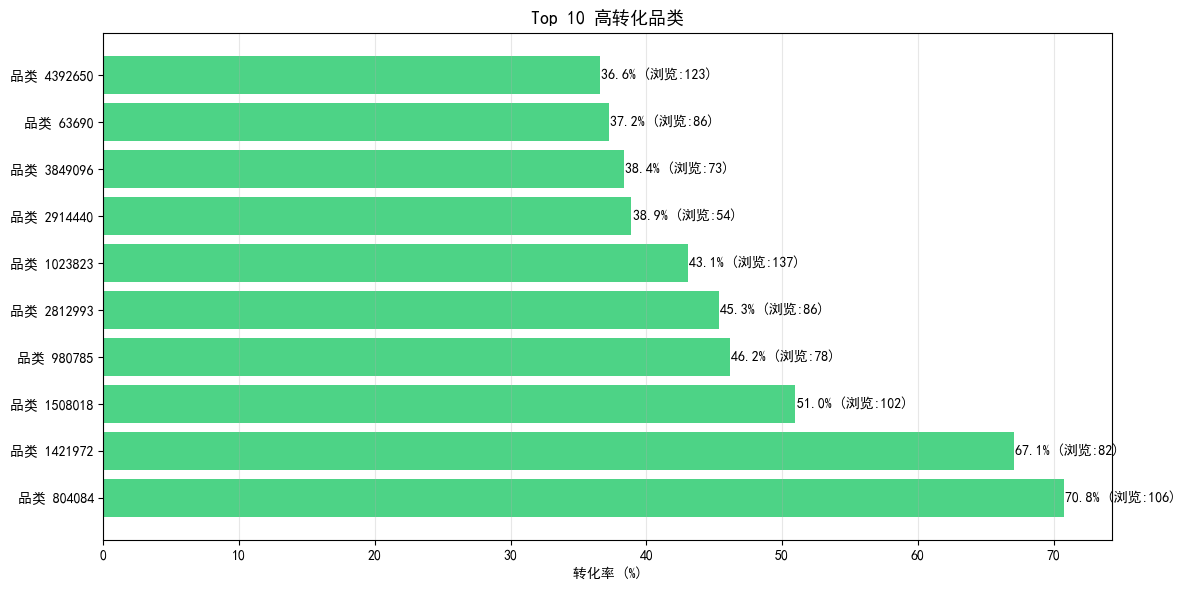

In [7]:
# 分品类统计
category_funnel = df.groupby(['category_id', 'behavior_type'])['user_id'].nunique().unstack(fill_value=0)

for col in ['pv', 'cart', 'fav', 'buy']:
    if col not in category_funnel.columns:
        category_funnel[col] = 0

category_funnel['conversion_rate'] = category_funnel['buy'] / category_funnel['pv'] * 100

# 过滤低流量品类
category_funnel = category_funnel[category_funnel['pv'] >= 50]

# Top 10 高转化品类
top10 = category_funnel.nlargest(10, 'conversion_rate')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top10)), top10['conversion_rate'], color='#2ecc71', alpha=0.85)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f'品类 {cid}' for cid in top10.index])
ax.set_xlabel('转化率 (%)')
ax.set_title('Top 10 高转化品类', fontsize=13, fontweight='bold')

# 添加数值标签
for i, (val, pv) in enumerate(zip(top10['conversion_rate'], top10['pv'])):
    ax.text(val + 0.1, i, f'{val:.1f}% (浏览:{pv})', va='center')

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'funnel_top_categories.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. 漏斗分析总结

### 核心发现
1. **整体转化率**：从浏览到购买的整体转化率是多少
2. **关键瓶颈**：哪一步转化率最低，是主要流失环节
3. **高峰时段**：哪个时段转化率最高
4. **品类差异**：不同品类的转化效率差异

### 业务建议
- 针对转化率低的环节进行优化
- 在高转化时段加大推广力度
- 重点扶持高转化品类